# 01 - EDA Open Bandit Dataset (Tydzien 1)

Cel tygodnia 1:
- instalacja pakietow (`obp`, `xgboost`, `shap`),
- pobranie danych OBD dla polityk `random` oraz `bts` (Bernoulli Thompson Sampling),
- podstawowe EDA: rozklad nagrod, rozklad akcji, brakujace wartosci,
- kluczowy wykres bias selekcji.

> Uwaga: jezeli pakiety nie sa zainstalowane, uruchom w terminalu:
> `pip install -r ../requirements.txt`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.dataset import OpenBanditDataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
# Zmienne konfiguracyjne - brak magic strings w dalszym kodzie
POLICY_RANDOM = "random"
POLICY_BTS    = "bts"
CAMPAIGN      = "all"

In [3]:
# KROK 2 - Zaladowanie danych
def load_obd_feedback(behavior_policy: str, campaign: str = CAMPAIGN):
    dataset  = OpenBanditDataset(behavior_policy=behavior_policy, campaign=campaign)
    feedback = dataset.obtain_batch_bandit_feedback()
    return dataset, feedback


dataset_random, feedback_random = load_obd_feedback(POLICY_RANDOM)
dataset_bts,    feedback_bts    = load_obd_feedback(POLICY_BTS)

print(f"[{POLICY_RANDOM}] n_rounds:", feedback_random["n_rounds"])
print(f"[{POLICY_BTS}]   n_rounds:", feedback_bts["n_rounds"])

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.
INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


[random] n_rounds: 10000
[bts]   n_rounds: 10000


In [4]:
# KROK 2 - Inspekcja surowych danych
def inspect_feedback(name: str, dataset: OpenBanditDataset, feedback: dict):
    print(f"\n{'='*55}")
    print(f"  Polityka: {name}")
    print(f"{'='*55}")
    print(f"  Klucze feedback : {list(feedback.keys())}")
    print(f"  n_rounds        : {feedback['n_rounds']}")
    print(f"  context shape   : {feedback['context'].shape}")
    print(f"  action_context  : {feedback['action_context'].shape}")
    print(f"  n_actions       : {dataset.n_actions}")
    print(f"  len_list        : {dataset.len_list}")

    action = feedback["action"]
    reward = feedback["reward"]
    print(f"\n  Unikalne akcje        : {len(set(action))}")
    print(f"  Proporcja reward=1 (CTR): {reward.mean():.4f}  ({reward.mean()*100:.2f}%)")

    print(f"\n  Pierwsze 5 wierszy (action / reward / pscore):")
    display(pd.DataFrame({
        "action": action[:5],
        "reward": reward[:5],
        "pscore": feedback["pscore"][:5],
    }))


inspect_feedback(POLICY_RANDOM, dataset_random, feedback_random)
inspect_feedback(POLICY_BTS,    dataset_bts,    feedback_bts)


  Polityka: random
  Klucze feedback : ['n_rounds', 'n_actions', 'action', 'position', 'reward', 'pscore', 'context', 'action_context']
  n_rounds        : 10000
  context shape   : (10000, 20)
  action_context  : (80, 5)
  n_actions       : 80
  len_list        : 3

  Unikalne akcje        : 80
  Proporcja reward=1 (CTR): 0.0038  (0.38%)

  Pierwsze 5 wierszy (action / reward / pscore):


,action,reward,pscore
0,14,0,0.0125
1,14,0,0.0125
2,27,0,0.0125
3,48,0,0.0125
4,36,0,0.0125



  Polityka: bts
  Klucze feedback : ['n_rounds', 'n_actions', 'action', 'position', 'reward', 'pscore', 'context', 'action_context']
  n_rounds        : 10000
  context shape   : (10000, 22)
  action_context  : (80, 5)
  n_actions       : 80
  len_list        : 3

  Unikalne akcje        : 80
  Proporcja reward=1 (CTR): 0.0042  (0.42%)

  Pierwsze 5 wierszy (action / reward / pscore):


,action,reward,pscore
0,79,0,0.087125
1,14,0,0.006235
2,18,0,0.061300
3,28,0,0.019430
4,65,0,0.019375


In [5]:
# KROK 2 - Tabela podsumowujaca obie polityki
def summarize_feedback(name: str, feedback: dict) -> dict:
    action  = np.asarray(feedback["action"])
    reward  = np.asarray(feedback["reward"])
    context = np.asarray(feedback["context"])
    return {
        "policy":             name,
        "n_rounds":           int(feedback["n_rounds"]),
        "n_actions_observed": int(np.unique(action).shape[0]),
        "reward_mean (CTR)":  float(reward.mean()),
        "reward_std":         float(reward.std()),
        "context_shape":      tuple(context.shape),
        "missing_pscore":     int(np.isnan(feedback["pscore"]).sum()),
        "missing_reward":     int(np.isnan(reward).sum()) if np.issubdtype(reward.dtype, np.floating) else 0,
    }


summary_df = pd.DataFrame([
    summarize_feedback(POLICY_RANDOM, feedback_random),
    summarize_feedback(POLICY_BTS,    feedback_bts),
])
summary_df

,policy,n_rounds,n_actions_observed,reward_mean (CTR),reward_std,context_shape,missing_pscore,missing_reward
0,random,10000,80,0.0038,0.061527,"(10000, 20)",0,0
1,bts,10000,80,0.0042,0.064671,"(10000, 22)",0,0


---
## KROK 3 - EDA

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


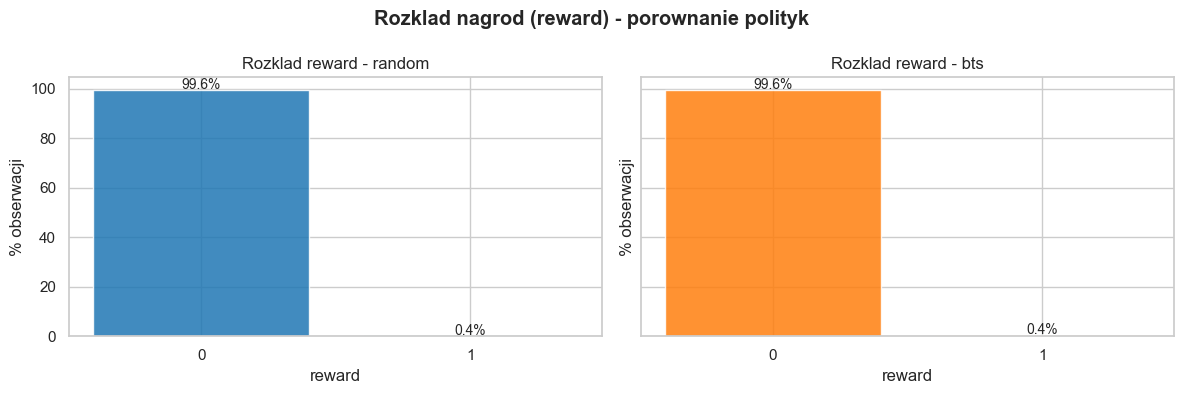

In [6]:
# KROK 3 - Wykres 1: rozklad nagrod (reward)
def plot_reward_distribution(fb_random: dict, fb_bts: dict):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, fb, name, color in zip(
        axes,
        [fb_random, fb_bts],
        [POLICY_RANDOM, POLICY_BTS],
        ["#1f77b4", "#ff7f0e"],
    ):
        counts = pd.Series(fb["reward"]).value_counts(normalize=True).sort_index()
        ax.bar(counts.index.astype(str), counts.values * 100, color=color, alpha=0.85)
        ax.set_title(f"Rozklad reward - {name}")
        ax.set_xlabel("reward")
        ax.set_ylabel("% obserwacji")
        for i, v in enumerate(counts.values):
            ax.text(i, v * 100 + 0.3, f"{v*100:.1f}%", ha="center", fontsize=10)

    plt.suptitle("Rozklad nagrod (reward) - porownanie polityk", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../figures/reward_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_reward_distribution(feedback_random, feedback_bts)

**Wykres 1 - obserwacja:** Oba rozklady sa silnie skosne - ponad 99% obserwacji to `reward=0`, a `reward=1` pojawia sie rzadko (CTR ~0.4%). Jest to typowy rozklad klikniec w systemach rekomendacji (rzadkie zdarzenia).

**Dlaczego to wazne:** Tak niski CTR oznacza duza wariancje estymatora IPS - nawet male bledy w propensity score moga silnie zaburzac wynik OPE.

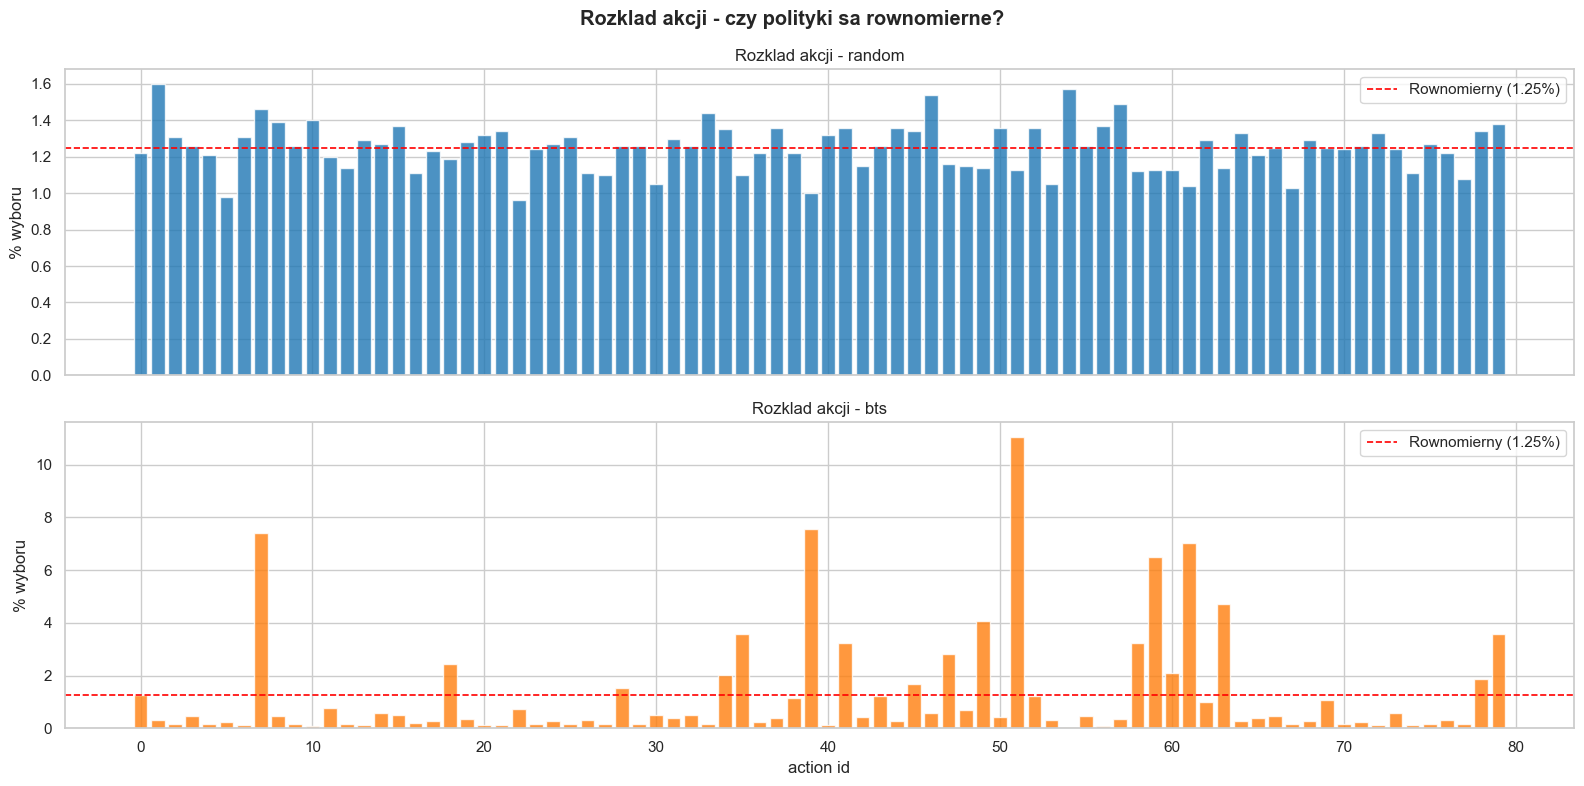

,random,bts
count,80.000000,80.000000
mean,0.012500,0.012500
std,0.001300,0.020505
min,0.009600,0.000400
25%,0.011475,0.001700
50%,0.012600,0.003850
75%,0.013325,0.012175
max,0.016000,0.110500


In [7]:
# KROK 3 - Wykres 2: rozklad akcji
def plot_action_distribution(fb_random: dict, fb_bts: dict):
    a_rand = pd.Series(fb_random["action"]).value_counts(normalize=True).sort_index()
    a_bts  = pd.Series(fb_bts["action"]).value_counts(normalize=True).sort_index()

    all_actions = sorted(set(a_rand.index) | set(a_bts.index))
    a_rand  = a_rand.reindex(all_actions, fill_value=0)
    a_bts   = a_bts.reindex(all_actions, fill_value=0)
    uniform = 100 / len(all_actions)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    for ax, series, name, color in zip(
        axes, [a_rand, a_bts], [POLICY_RANDOM, POLICY_BTS], ["#1f77b4", "#ff7f0e"]
    ):
        ax.bar(all_actions, series.values * 100, color=color, alpha=0.8)
        ax.axhline(uniform, color="red", ls="--", lw=1.2,
                   label=f"Rownomierny ({uniform:.2f}%)")
        ax.set_title(f"Rozklad akcji - {name}")
        ax.set_ylabel("% wyboru")
        ax.legend()

    axes[1].set_xlabel("action id")
    plt.suptitle("Rozklad akcji - czy polityki sa rownomierne?", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../figures/action_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({"random": a_rand, "bts": a_bts})


action_distribution = plot_action_distribution(feedback_random, feedback_bts)
action_distribution.describe()

**Wykres 2 - obserwacja:** Polityka `random` ma niemal rownomierny rozklad akcji (~1.25% kazda), natomiast `bts` koncentruje wybory na podzbiorze akcji - czesc ma wyraznie wyzszy udzial, pozostale prawie zerowy.

**Dlaczego to wazne:** Koncentracja `bts` na konkretnych akcjach to serce **selection bias** - obserwujemy wiecej probek dla akcji, ktore *wydaja sie* lepsze, a mniej dla pozostalych. Naiwne porownanie CTR per-akcja jest mylace i wymaga korekcji (IPS/DR).

---
## KROK 4 - Kluczowy wykres: bias selekcji

Cel: pokazac, ze naiwne porownanie `P(reward=1 | action)` jest **mylace**, bo `bts` eksploruje akcje nierowniomiernie - akcje czesciej wybierane maja wiecej szans na "wygladzanie dobrze" w danych.

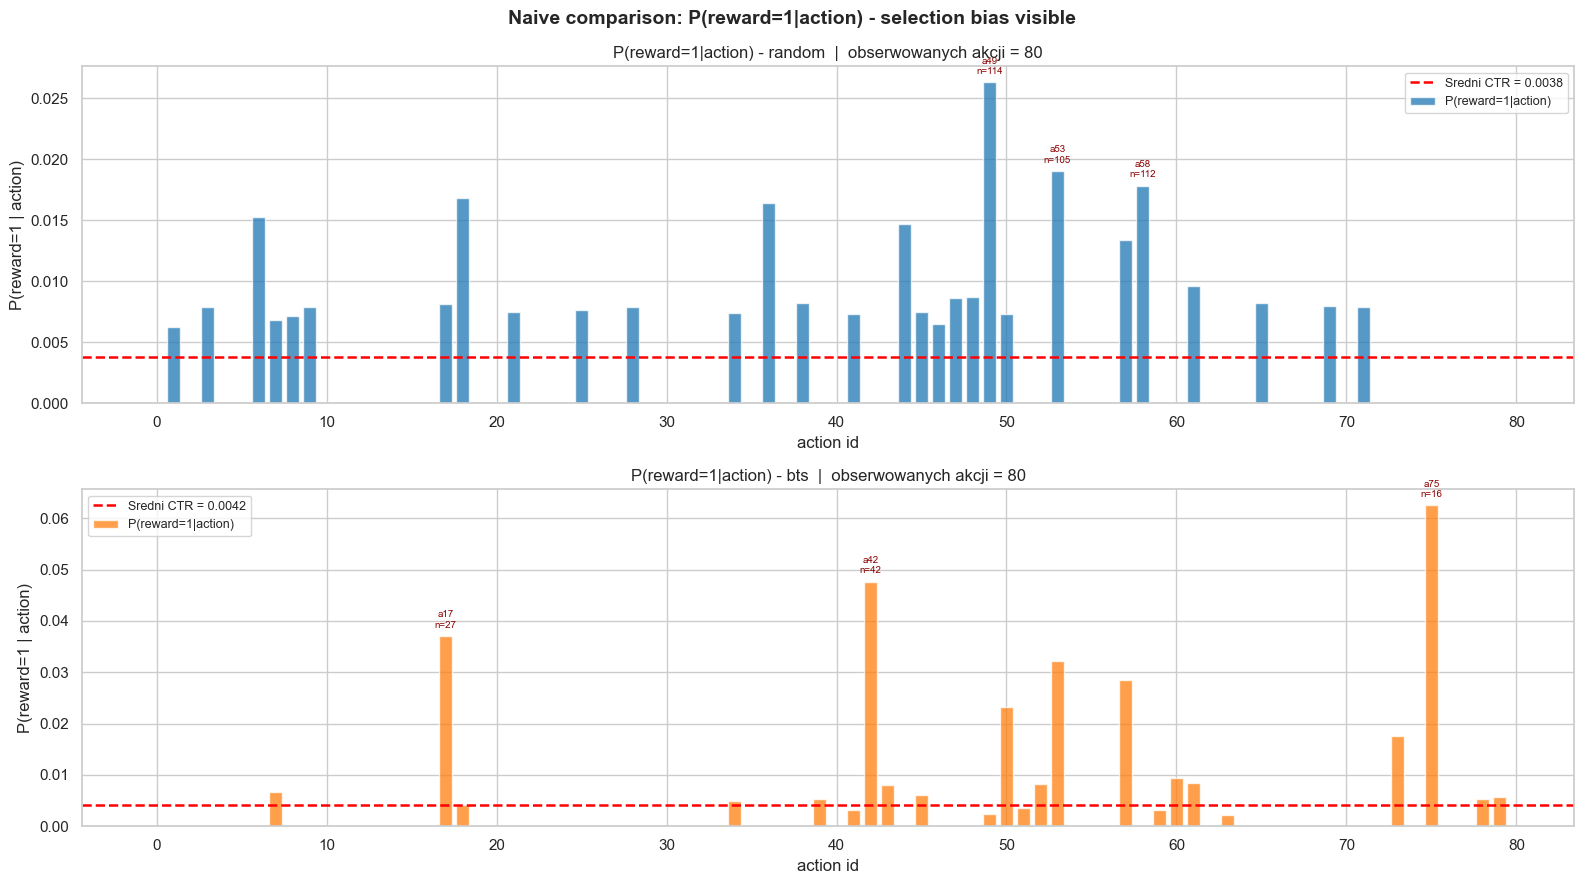

Sredni CTR - random: 0.0038
Sredni CTR - bts:    0.0042
Najlepsza akcja wg bts: action=75  CTR=0.0625  n_obs=16


In [9]:
# KROK 4 - P(reward=1 | action) + selection bias
def compute_action_ctr(feedback: dict) -> pd.DataFrame:
    df = pd.DataFrame({"action": feedback["action"], "reward": feedback["reward"]})
    return df.groupby("action")["reward"].agg(ctr="mean", n_obs="count")


ctr_random = compute_action_ctr(feedback_random)
ctr_bts    = compute_action_ctr(feedback_bts)

mean_ctr_random = feedback_random["reward"].mean()
mean_ctr_bts    = feedback_bts["reward"].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

for ax, ctr_df, mean_ctr, name, color in zip(
    axes,
    [ctr_random, ctr_bts],
    [mean_ctr_random, mean_ctr_bts],
    [POLICY_RANDOM, POLICY_BTS],
    ["#1f77b4", "#ff7f0e"],
):
    ax.bar(ctr_df.index, ctr_df["ctr"], color=color, alpha=0.75,
           label="P(reward=1|action)")
    ax.axhline(mean_ctr, color="red", linestyle="--", linewidth=1.8,
               label=f"Sredni CTR = {mean_ctr:.4f}")

    for action_id, val in ctr_df["ctr"].nlargest(3).items():
        n = int(ctr_df.loc[action_id, "n_obs"])
        ax.annotate(
            f"a{action_id}\nn={n}",
            xy=(action_id, val), xytext=(0, 6),
            textcoords="offset points",
            ha="center", fontsize=7, color="darkred",
        )

    ax.set_title(f"P(reward=1|action) - {name}  |  obserwowanych akcji = {len(ctr_df)}")
    ax.set_xlabel("action id")
    ax.set_ylabel("P(reward=1 | action)")
    ax.legend(fontsize=9)

fig.suptitle(
    "Naive comparison: P(reward=1|action) - selection bias visible",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig("../figures/selection_bias.png", dpi=150, bbox_inches="tight")
plt.show()

top_action = int(ctr_bts["ctr"].idxmax())
print(f"Sredni CTR - {POLICY_RANDOM}: {mean_ctr_random:.4f}")
print(f"Sredni CTR - {POLICY_BTS}:    {mean_ctr_bts:.4f}")
print(f"Najlepsza akcja wg {POLICY_BTS}: action={top_action}",
      f" CTR={ctr_bts.loc[top_action,'ctr']:.4f}",
      f" n_obs={int(ctr_bts.loc[top_action,'n_obs'])}")

### Ktora akcja wyglada najlepiej w `bts`? Czy mozemy jej zaufac? Dlaczego nie?

Akcja z najwyzszym `P(reward=1|action)` w danych `bts` **wyglada na najlepsza** - jej obserwowany CTR wyraznie wystaje ponad srednia.

**Nie mozemy jej ufac z trzech powodow:**

1. **Selection bias:** `bts` celowo eksponuje te akcje *czesciej*, bo wczesnie ocenila ja jako obiecujaca. Wynik jest efektem petli: dobra ocena -> wiecej ekspozycji -> wiecej klikniec -> jeszcze lepsza ocena. To nie jest bezstronne oszacowanie wartosci akcji.

2. **Confounding kontekstowy:** `bts` nie wybiera losowo - prezentuje akcje uzytkownikom, ktorzy *bardziej pasuja* do danego produktu. Porownujac surowe CTR, mieszamy efekt akcji z efektem doboru uzytkownika.

3. **Nierowna liczba probek:** Akcje rzadko wybierane przez `bts` maja `n_obs` rzedu kilku-kilkunastu, co daje bardzo szeroki przedział ufnosci. Ich niski obserwowany CTR nie oznacza, ze sa zle - po prostu brakuje danych.

**Wniosek:** Do rzetelnego porownania potrzebujemy estymatora Off-Policy Evaluation (IPS, DR, DM), ktory koryguje roznice w propensity score miedzy politykami.